# TP1 Vision Artificial - Panoramica

#### by: Tomás Vocos Conesa - Martin Ariel DeHieronymis - Zoe Larisson
    

### Imports:


In [14]:
import numpy as np 
from matplotlib import pyplot as plt
import cv2

from utils import *

# 1. Deteccion y Descripcion de caracteristicas Visuales
testeo deteccion y descripcion con funciones de Opencv en aluna de las imagenes

In [15]:
cuadro_0_img = cv2.imread('inputs/cuadro_0.jpg')
cuadro_1_img = cv2.imread('inputs/cuadro_1.jpg')
cuadro_2_img = cv2.imread('inputs/cuadro_2.jpg')

#### SIFT:
Esta funcion da los keypoints y sus respectivos descriptores. Hay muchas funciones de este estilo en la libreria pero en teoria esta de es las mas robustas. 

La misma internamente convierte la imagen a grayscale y trabaja con un solo canal de intensidad. Debido a esto no hace falta manualmente pasar a grayscale

In [16]:
sift = cv2.SIFT_create(nfeatures=200)
kp_cuadro0, descr_cuadro0 = sift.detectAndCompute(cuadro_0_img, None)

img_kp = cuadro_0_img.copy() # grafico los keypoints manualmente (la funcion Draw_Keypoints es malisima)
for kp in kp_cuadro0:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    r = max(7, int(kp.size / 3))
    cv2.circle(img_kp, (x, y), r + 2, (0, 0, 0), -1)      # halo negro
    cv2.circle(img_kp, (x, y), r, (0, 0, 255), -1)        # rojo llamativo (BGR)

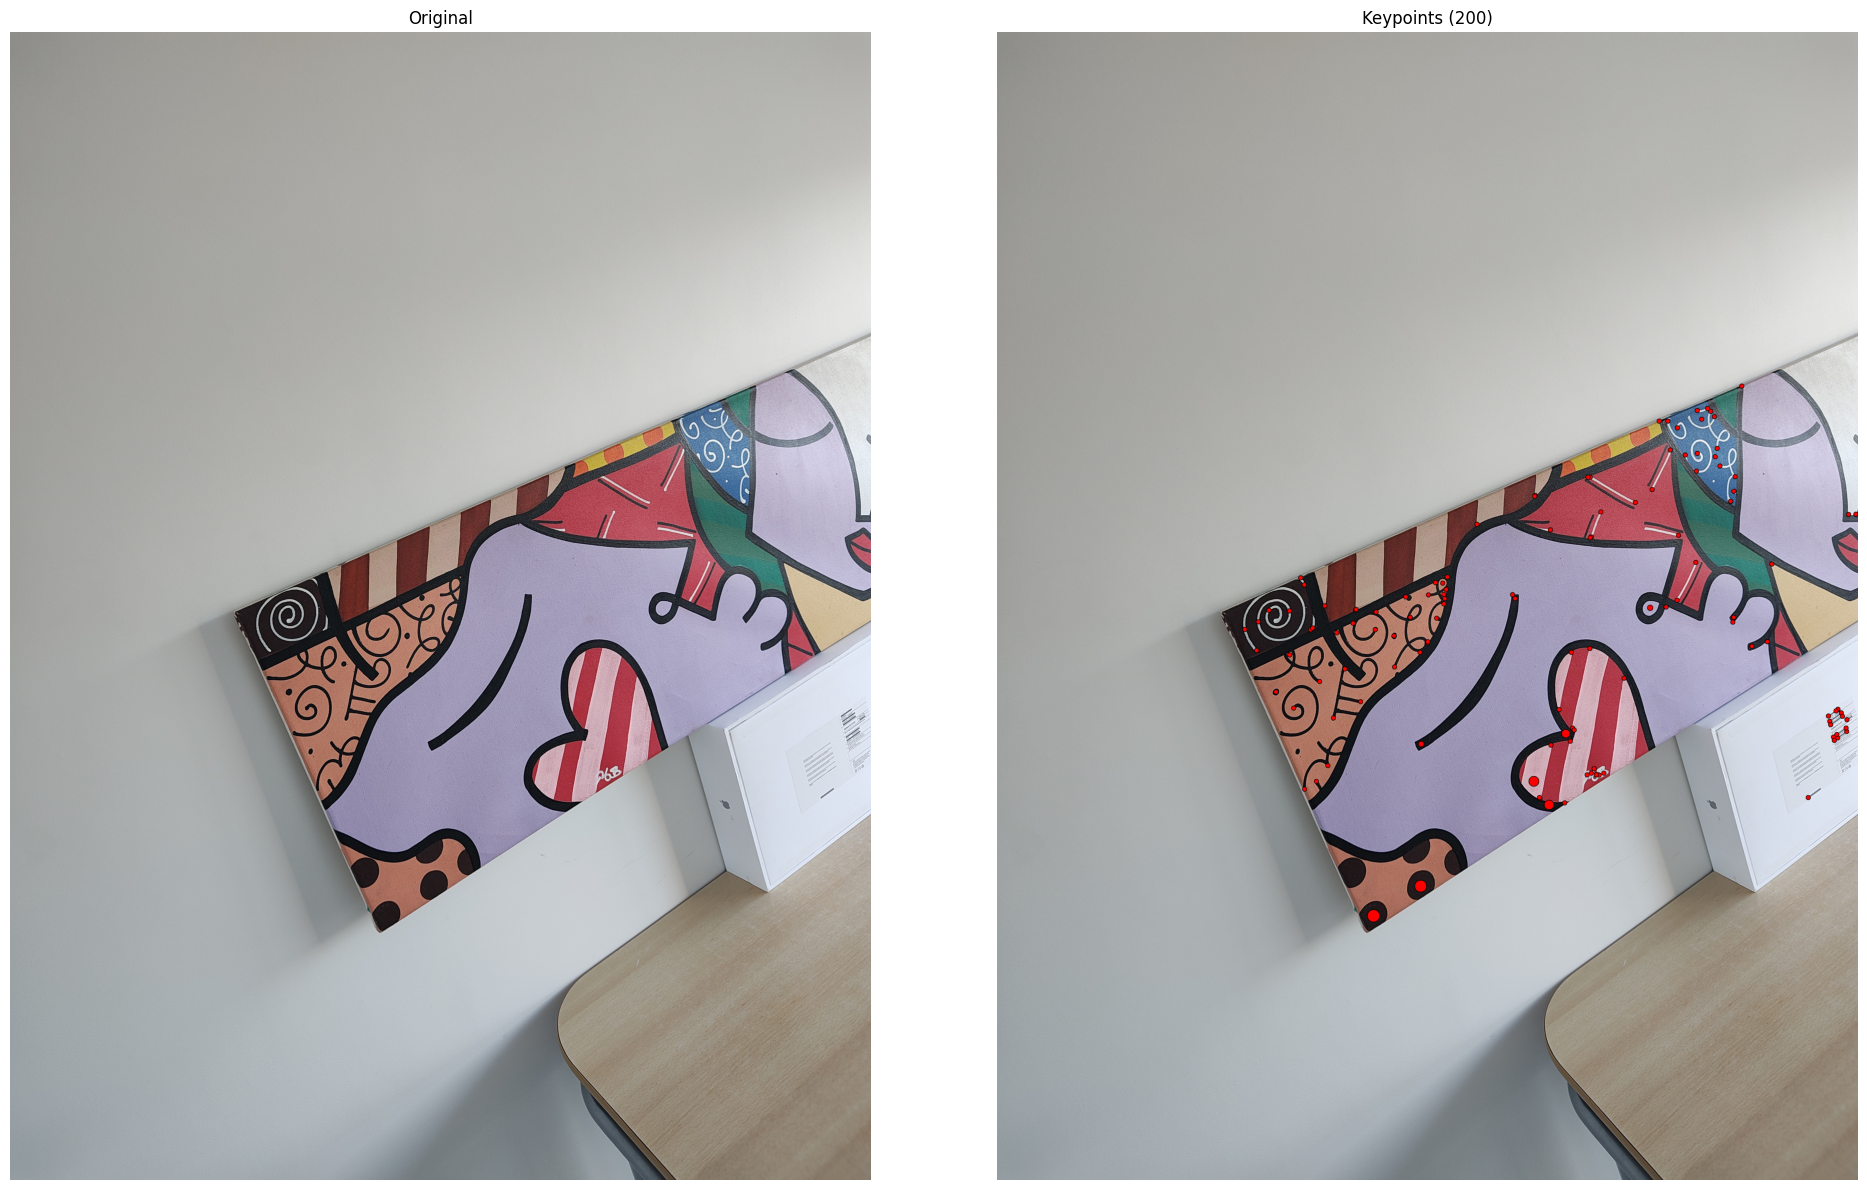

In [17]:
img_kp_rgb = cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)
img_prueba_rgb = cv2.cvtColor(cuadro_0_img, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(20, 12))  # más grande
axs[0].imshow(img_prueba_rgb)
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow(img_kp_rgb)
axs[1].set_title(f'Keypoints ({len(kp_cuadro0)})')
axs[1].axis('off')

plt.tight_layout()
plt.show()

Hago lo mismo con las otras imagenes del cuadro y veo como matchenan los features 

#### Funciones auxiliares: matching y ploteo
Modularizo el matching y el ploteo en dos funciones:
- `plot_matches`: dibuja los matches entre dos imagenes usando `cv2.drawMatches`
- `detectar_matches`: matchea descriptores con `BFMatcher` + ratio test de Lowe, y opcionalmente llama a `plot_matches` para graficar

Matches buenos: 51 de 200 totales


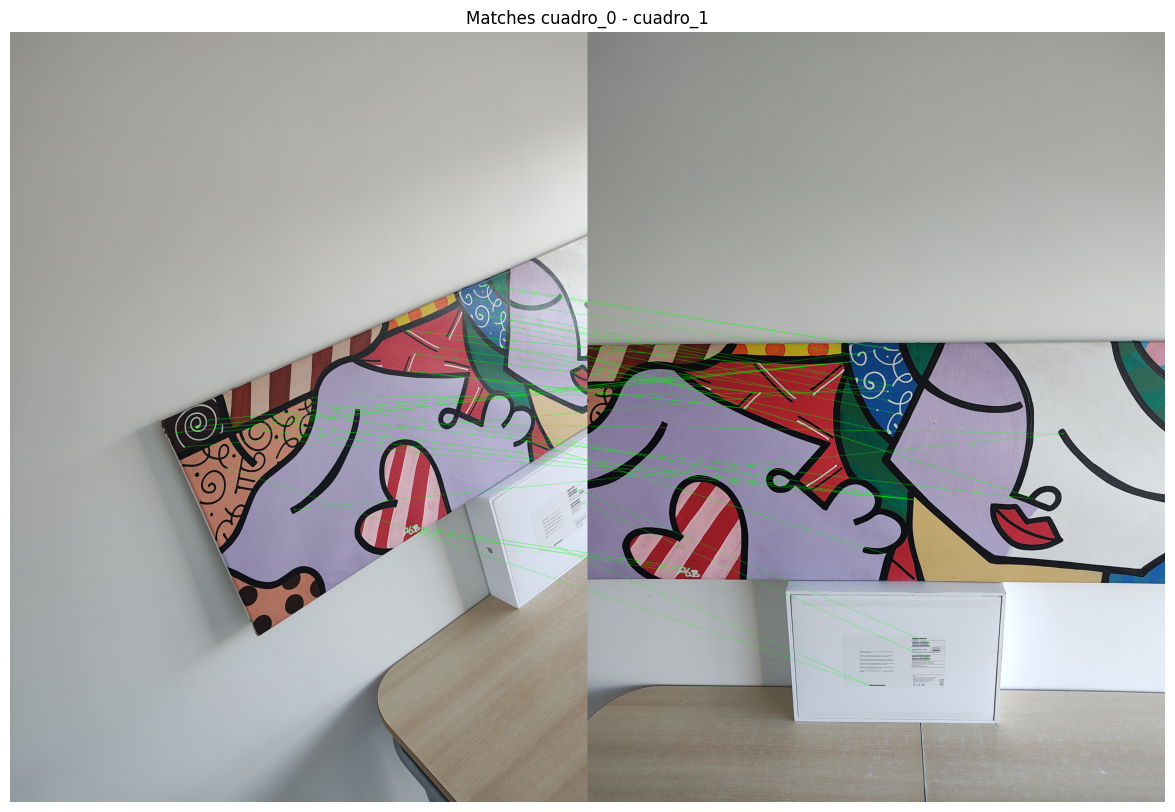

In [18]:
kp_cuadro1, descr_cuadro1 = sift.detectAndCompute(cuadro_1_img, None)

good_matches_01 = detectar_matches(
    descr_cuadro0, descr_cuadro1, plot=True,
    img1=cuadro_0_img, kp1=kp_cuadro0, img2=cuadro_1_img, kp2=kp_cuadro1,
    titulo='Matches cuadro_0 - cuadro_1'
)

Matches buenos: 46 de 200 totales


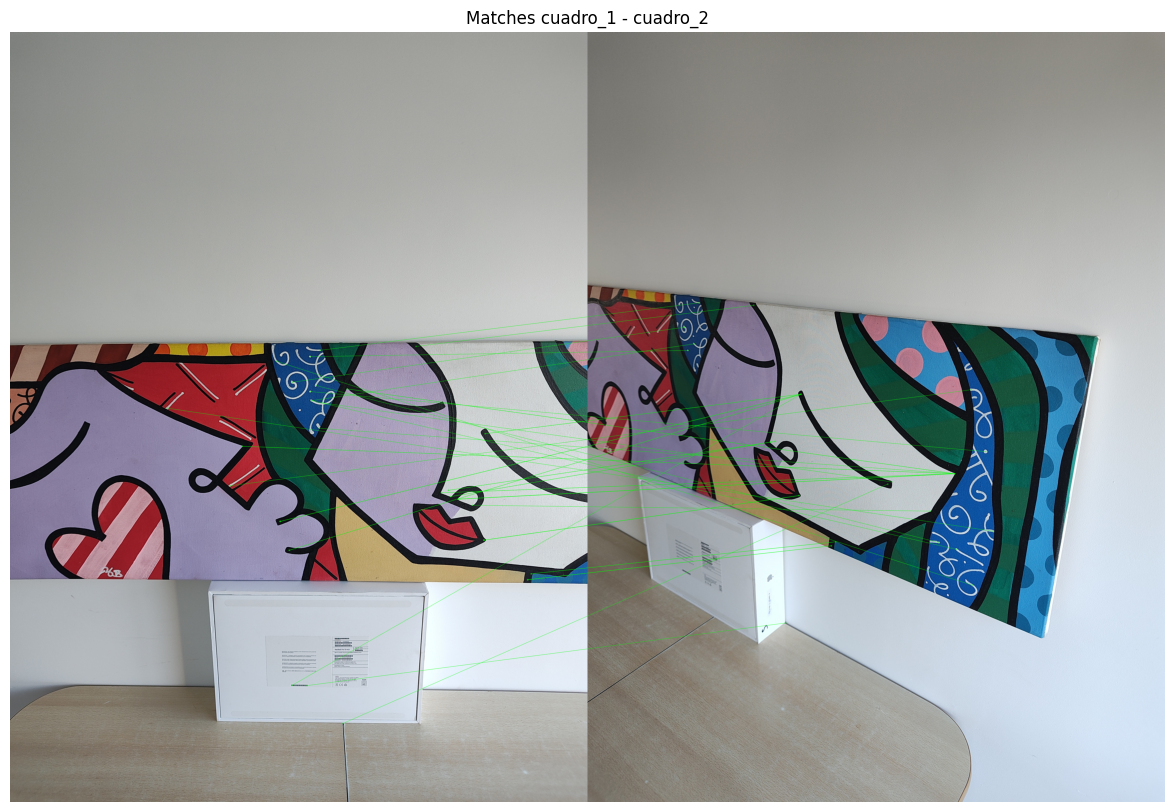

In [19]:
kp_cuadro2, descr_cuadro2 = sift.detectAndCompute(cuadro_2_img, None)

good_matches_12 = detectar_matches(
    descr_cuadro1, descr_cuadro2, plot=True,
    img1=cuadro_1_img, kp1=kp_cuadro1, img2=cuadro_2_img, kp2=kp_cuadro2,
    titulo='Matches cuadro_1 - cuadro_2'
)

# 3.2 A-MNS

In [20]:
sift = cv2.SIFT_create()  # sin limitar nfeatures, detectamos todos primero
keypoints, descriptors = sift.detectAndCompute(cuadro_0_img, None)

print(f'Keypoints detectados originalmente: {len(keypoints)}')

keypoints_anms = anms(keypoints, n_max=200)

print(f'Keypoints tras ANMS: {len(keypoints_anms)}')

Keypoints detectados originalmente: 13636
Keypoints tras ANMS: 200


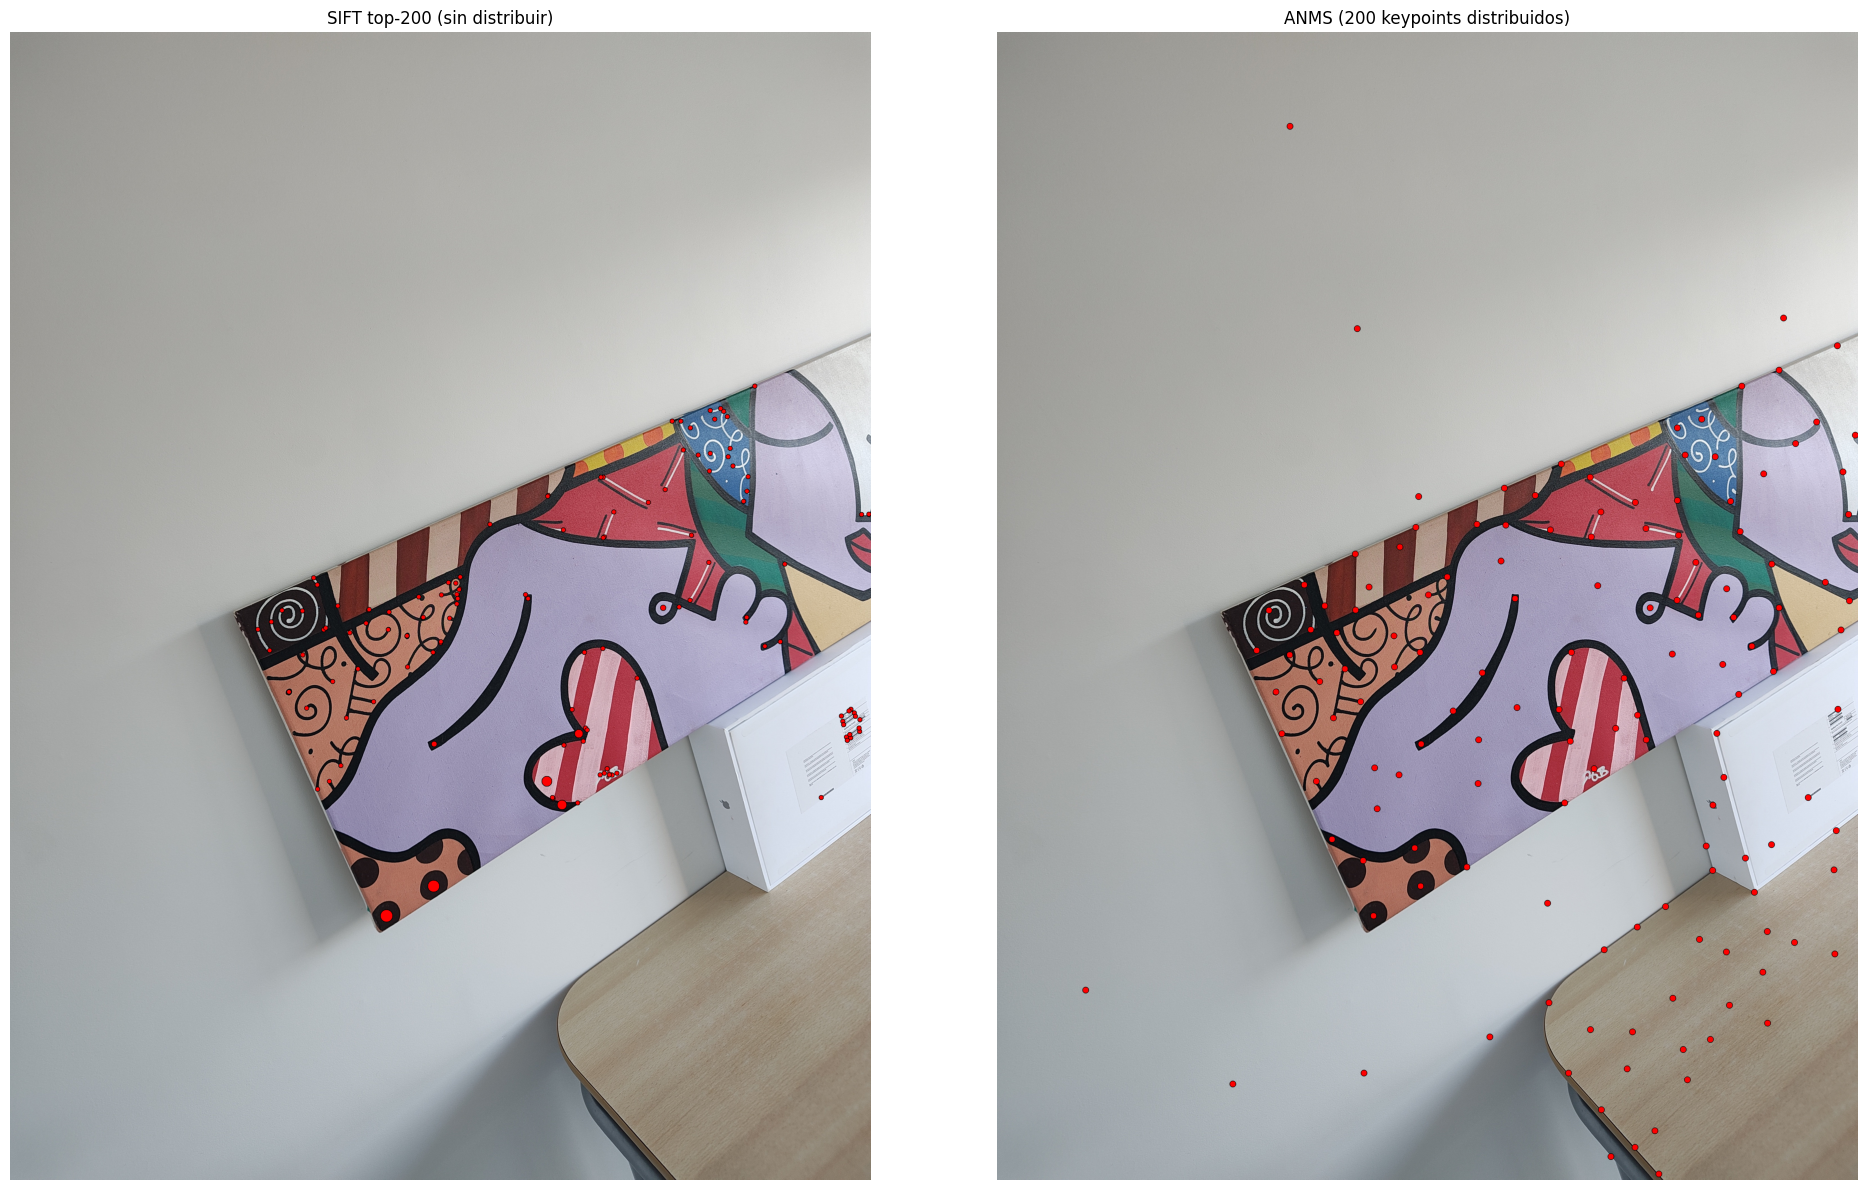

In [21]:
img_anms = cuadro_0_img.copy()
for kp in keypoints_anms:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    # r = max(7, int(kp.size / 3))
    r = 10
    cv2.circle(img_anms, (x, y), r + 2, (0, 0, 0), -1)    # halo negro
    cv2.circle(img_anms, (x, y), r, (0, 0, 255), -1)      # rojo llamativo (BGR)

fig, axs = plt.subplots(1, 2, figsize=(20, 12))

axs[0].imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'SIFT top-{len(kp_cuadro0)} (sin distribuir)')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_anms, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'ANMS ({len(keypoints_anms)} keypoints distribuidos)')
axs[1].axis('off')

plt.tight_layout()
plt.show()